**Taller 6 - Problema de clasificación usando un ensamble de árboles**

Diego Andrés Burbano A.


## 1. Importar librerias necesarias para el modelo

In [39]:
#Importar librerias necesarias
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 100);
import seaborn as sns
import time
from random import random, seed
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from scipy.stats import uniform, randint
from sklearn.preprocessing import MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from random import random, seed
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split, KFold, cross_validate, cross_val_predict, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, accuracy_score , average_precision_score, f1_score, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
from xgboost.sklearn import XGBClassifier
from xgboost import plot_importance
from collections import Counter

import warnings # Ignorar las warnings
warnings.filterwarnings("ignore")

import os
from google.colab import drive

## 2. Carga de datos

In [40]:
# En esta celda se esta montando el drive  que tiene almacenado los datos en la ruta MyDrive/datos
drive.mount('/content/drive', force_remount=True)

# una vez se montó el drive, se cambia la ruta de archivo de 'content' de Colab por la ruta de Google Drive ('/MyDrive/datos/')
os.chdir('/content/drive/MyDrive/datos/')

Mounted at /content/drive


Revisión preliminar de datos

In [41]:
df = pd.read_csv('./train_t6.csv', sep=',').reset_index(drop=True)
df.head()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,b,t,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,0,22.0,3.0,1.0,2.0,60.0,278.63,0.06,19.56,14.25,5448.79,0.09,302.71,17,1,1,0,16.0,9.0,38.0,22.0,5.0,False
1,1,14.0,2.0,1.0,2.0,32.0,151.27,0.14,7.00,21.11,936.71,0.05,52.04,11,0,1,0,11.0,11.0,18.0,14.0,3.0,False
2,2,11.0,2.0,1.0,2.0,45.0,197.65,0.11,8.05,22.76,1754.01,0.07,97.45,8,0,1,0,12.0,11.0,28.0,17.0,3.0,False
3,3,8.0,1.0,1.0,1.0,23.0,94.01,0.19,5.25,17.86,473.66,0.03,26.31,4,0,2,0,8.0,6.0,16.0,7.0,1.0,True
4,4,11.0,2.0,1.0,2.0,17.0,60.94,0.18,5.63,12.44,365.67,0.02,20.31,7,0,2,0,7.0,6.0,10.0,10.0,3.0,False


In [42]:
#Cantidad y dimensionalidad de los datos
df.shape

(101763, 23)

In [43]:
#Perfilamiento de los datos
df.describe()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,b,t,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount
count,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,1.017630e+05,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000,101763.000000
mean,50881.000000,37.347160,5.492684,2.845022,3.498826,96.655995,538.280956,0.111634,13.681881,27.573007,2.085359e+04,0.179164,1141.357982,22.802453,1.773945,3.979865,0.196604,11.896131,15.596671,57.628116,39.249698,9.839549
std,29376.592059,54.600401,7.900855,4.631262,5.534541,171.147191,1270.791601,0.100096,14.121306,22.856742,1.905714e+05,0.421844,9862.795472,38.541010,5.902412,6.382358,0.998906,6.749549,18.064261,104.537660,71.692309,14.412769
min,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25440.500000,13.000000,2.000000,1.000000,1.000000,25.000000,97.670000,0.050000,5.600000,15.560000,5.647300e+02,0.030000,31.380000,7.000000,0.000000,1.000000,0.000000,8.000000,7.000000,15.000000,10.000000,3.000000
50%,50881.000000,22.000000,3.000000,1.000000,2.000000,51.000000,232.790000,0.090000,9.820000,23.360000,2.256230e+03,0.080000,125.400000,14.000000,0.000000,2.000000,0.000000,11.000000,12.000000,30.000000,20.000000,5.000000
75%,76321.500000,42.000000,6.000000,3.000000,4.000000,111.000000,560.250000,0.150000,18.000000,34.340000,1.019324e+04,0.190000,565.920000,26.000000,1.000000,5.000000,0.000000,16.000000,20.000000,66.000000,45.000000,11.000000
max,101762.000000,3442.000000,404.000000,165.000000,402.000000,8441.000000,80843.080000,1.000000,418.200000,569.780000,1.684662e+07,26.950000,935923.390000,2824.000000,344.000000,219.000000,43.000000,410.000000,1026.000000,5420.000000,3021.000000,503.000000


In [44]:
#Revisión de datos faltantes
print(f'Datos nulos: \n {df.isna().sum()}')

Datos nulos: 
 id                   0
loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              0
uniq_Opnd            0
total_Op             0
total_Opnd           0
branchCount          0
defects              0
dtype: int64


No existen datos faltantes o nulos.

In [45]:
#Identificación de datos repetidos
print(f'Datos duplicados: {df.duplicated().sum()}')

Datos duplicados: 0


No existen datos duplicados o repetidos.

##3. Preparación de los sets de entrenamiento

In [46]:
#Mapa para transformar la variable objetivo
target_map={
    False:0,
    True: 1
}

# Separación de variable objetivo y variables explicativas
X = df.loc[:, df.columns != 'defects']
y = df['defects']

# Aplicar el reemplazo
y_numeric = np.array(y.replace(target_map))

([<matplotlib.patches.Wedge at 0x7fca8f97cfe0>,
 [Text(-0.8327451950972532, 0.7187040002966714, 'False'),
  Text(0.8327450865759589, -0.7187041260376894, 'True')],
 [Text(-0.45422465187122896, 0.39202036379818433, '77.3%'),
  Text(0.4542245926777957, -0.39202043238419415, '22.7%')])

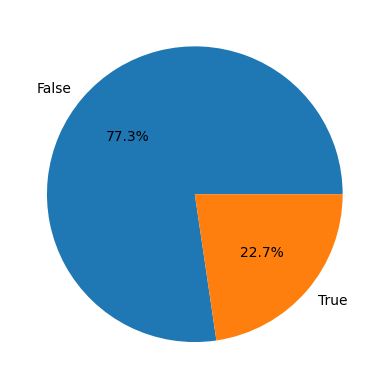

In [47]:
#Observar balance de clases

#Contar y normalizar
dfsizes = y.value_counts()/y.shape[0]
#Crear figura
fig, ax = plt.subplots()
#Pintar
ax.pie(list(dfsizes),labels=list(dfsizes.index) ,autopct='%1.1f%%')

El resultado de la revision de las clases muestra un desbalanceo hacia la clase "False" o 0.

## 4. Modelo XGBoost Básico

Modelo inicial o linea base con parámetros XGBoost por defecto: n_estimators = 100, max_depth = 6, learning_rate = 0.3, entre otros.


In [48]:
# Inicializar el modelo xgboost
model = xgb.XGBClassifier()
# Inicializar el instrumento de cross validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=52)
# Establecer métricas de evaluación
scoring = ['accuracy','precision', 'recall', 'f1']
# Realizar scores para el modelo base
scores_base = cross_validate(model, X, y, cv=kfold, scoring=scoring, verbose = 10, n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:    8.3s remaining:    5.6s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    9.7s finished


Presentación de resultados del modelo base:

In [49]:
display(pd.DataFrame(scores_base))
print("Accuracy: %.2f%% (%.2f%%)" % (scores['test_accuracy'].mean()*100, scores['test_accuracy'].std()*100))

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,3.648172,0.160764,0.810790,0.636169,0.385866,0.480367
1,3.234607,0.165311,0.812165,0.647719,0.375461,0.475367
2,2.334084,0.123733,0.809365,0.636499,0.370475,0.468347
3,2.049465,0.112762,0.809404,0.630011,0.385082,0.477998
4,1.304482,0.091980,0.810633,0.639062,0.378062,0.475075


Accuracy: 81.05% (0.10%)


Funciones para presentación y visualización de resultados:

In [50]:
def report_best_scores(results, n_top=3):
    # Esta función espera una instancia de resultados de búsqueda de cross validation, por ejemplo: search.cv_results_
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_accuracy'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.3f} (std: {1:.3f})".format(
                  results['mean_test_accuracy'][candidate],
                  results['std_test_accuracy'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")
    # Retorna los parámetros del mejor modelo basado en accuracy.
    return list(results.sort_values("rank_test_accuracy")['params'])[0]

def see_results(results):
    # Esta función espera una instancia de pandas dataframe de los resultados de búsqueda de cross validation, por ejemplo: pd.DataFrame(search.cv_results_)
    display(results[results.columns.drop(list(results.filter(regex='split')))].sort_values("rank_test_accuracy"))

## 5. Mejor Modelo XGBoost con GridSearch:

Se presenta el código para el cálculo de los mejores hiperparámetros para el modelo XGBoost:

In [51]:
model1 = XGBClassifier()
estimadores = [200, 250, 275]
profundidad = [1, 2]
learning_rate = [0.1, 0.12, 0.14]
param_grid = dict(n_estimators=estimadores, max_depth=profundidad, learning_rate=learning_rate)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}
grid_search = GridSearchCV(model1, param_grid, scoring=scoring, refit = 'accuracy', n_jobs=-1, cv=kfold)
grid_result = grid_search.fit(X, y)
print(f"Resultados del GridSearch CV - Mejores resultados: {grid_search.best_score_:.4%} y Mejores parámetros: {grid_search.best_params_} ")



Resultados del GridSearch CV - Mejores resultados: 81.5070% y Mejores parámetros: {'learning_rate': 0.12, 'max_depth': 2, 'n_estimators': 250} 


Como resultado del gridsearch se encontró que la mejor combinación de hiperparámetros es la siguiente:


*   Tasa de aprendizaje (Learning rate) = 0.12
*   Produnfidad máxima de los árboles (Max_depth) = 2
*   Número de árboles o estimadores (n_estimators) = 250

Se prepara un cross validation con 5 distintos cortes de datos (n_splits = 5) para encontrar los resultados del mejor modelo encontrado en el paso anterior:

In [52]:
mejor_modelo = grid_search.best_estimator_
mejores_resultados = cross_validate(mejor_modelo, X, y, cv=kfold, scoring=scoring, verbose = 10, n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:    6.5s remaining:    4.3s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    8.0s finished


In [53]:
mejores_resultados

{'fit_time': array([3.80496097, 3.89890003, 2.38882565, 2.37857342, 1.46674728]),
 'score_time': array([0.11003256, 0.10056043, 0.0962286 , 0.10075808, 0.05924273]),
 'test_accuracy': array([0.81555545, 0.81761902, 0.81275488, 0.81510417, 0.814318  ]),
 'test_precision': array([0.65246716, 0.66878981, 0.64786136, 0.64868651, 0.65174672]),
 'test_recall': array([0.39843919, 0.38694992, 0.38088012, 0.40156114, 0.3882506 ]),
 'test_f1': array([0.49475101, 0.49024993, 0.47972696, 0.49604928, 0.48661867])}

In [54]:
display(pd.DataFrame(mejores_resultados))
print("Accuracy: %.2f%% (%.2f%%)" % (mejores_resultados['test_accuracy'].mean()*100, mejores_resultados['test_accuracy'].std()*100))

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,3.804961,0.110033,0.815555,0.652467,0.398439,0.494751
1,3.898900,0.100560,0.817619,0.668790,0.386950,0.490250
2,2.388826,0.096229,0.812755,0.647861,0.380880,0.479727
3,2.378573,0.100758,0.815104,0.648687,0.401561,0.496049
4,1.466747,0.059243,0.814318,0.651747,0.388251,0.486619


Accuracy: 81.51% (0.16%)


Se utilizan los procedimientos creados anteriormente para visualizar los resultados basados en el parámetro scoring definido previamente:

In [55]:
resultados = pd.DataFrame(grid_search.cv_results_)
see_results(resultados)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,mean_test_precision,std_test_precision,rank_test_precision,mean_test_recall,std_test_recall,rank_test_recall,mean_test_f1,std_test_f1,rank_test_f1
10,3.113520,0.686535,0.119965,0.022796,0.12,2,250,"{'learning_rate': 0.12, 'max_depth': 2, 'n_est...",0.815070,0.001591,1,0.653910,0.007643,1,0.391216,0.007655,11,0.489479,0.005913,5
3,2.643069,0.677906,0.133035,0.042541,0.10,2,200,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.815051,0.001589,2,0.653332,0.007259,6,0.392127,0.007857,4,0.490031,0.006150,1
4,2.587185,0.231183,0.097384,0.003044,0.10,2,250,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.815011,0.001661,3,0.653561,0.007859,3,0.391346,0.007698,9,0.489483,0.006013,4
11,2.611857,0.126287,0.105638,0.003012,0.12,2,275,"{'learning_rate': 0.12, 'max_depth': 2, 'n_est...",0.815002,0.001654,4,0.653436,0.007566,4,0.391476,0.008268,8,0.489546,0.006479,3
5,3.248369,0.779850,0.132783,0.036678,0.10,2,275,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.814982,0.001488,5,0.653264,0.007314,7,0.391650,0.007758,6,0.489634,0.005813,2
15,4.301865,0.954156,0.210926,0.129517,0.14,2,200,"{'learning_rate': 0.14, 'max_depth': 2, 'n_est...",0.814795,0.001536,6,0.653426,0.006848,5,0.389525,0.008469,14,0.488014,0.006607,13
17,2.487315,0.183785,0.097675,0.017352,0.14,2,275,"{'learning_rate': 0.14, 'max_depth': 2, 'n_est...",0.814795,0.001608,7,0.653728,0.007314,2,0.388962,0.008406,16,0.487654,0.006579,15
9,2.001851,0.018014,0.086793,0.001565,0.12,2,200,"{'learning_rate': 0.12, 'max_depth': 2, 'n_est...",0.814785,0.001653,8,0.652714,0.008134,9,0.390913,0.007745,12,0.488900,0.005898,8
16,3.801477,0.472072,0.153722,0.042619,0.14,2,250,"{'learning_rate': 0.14, 'max_depth': 2, 'n_est...",0.814638,0.001555,9,0.652908,0.007340,8,0.389092,0.008102,15,0.487529,0.006242,16
12,2.122035,0.468555,0.084117,0.019138,0.14,1,200,"{'learning_rate': 0.14, 'max_depth': 1, 'n_est...",0.814402,0.001387,10,0.651326,0.004669,12,0.389742,0.005552,13,0.487654,0.005196,14


In [56]:
best_model_params = report_best_scores(resultados)
best_model_params

Model with rank: 1
Mean validation score: 0.815 (std: 0.002)
Parameters: {'learning_rate': 0.12, 'max_depth': 2, 'n_estimators': 250}

Model with rank: 2
Mean validation score: 0.815 (std: 0.002)
Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}

Model with rank: 3
Mean validation score: 0.815 (std: 0.002)
Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 250}



{'learning_rate': 0.12, 'max_depth': 2, 'n_estimators': 250}

## 6. Modelo XGBoost con costos:

Se prepara un tercer modelo ajustado para considerar el desbalanceo de los datos revisado anteriormente. Para ello utilizaremos el parámetro scale_pos_weight de XGBoost el cual mide la proporción entre número de negativos y positivos de la variable objetivo y:

In [57]:
#Revisamos la proporción de desbalanceo de las clases
conteo = Counter(y)
neg, pos = conteo[0], conteo[1]
scale = neg / pos
print(f"Negativos: {neg}, Positivos: {pos}, scale_pos_weight={scale:.2f}")

Negativos: 78699, Positivos: 23064, scale_pos_weight=3.41


Este tercer modelo le da mas "peso" a los positivos para que el modelo no los ignore.

In [58]:
mejor_modelo_costos = xgb.XGBClassifier(**grid_search.best_params_, scale_pos_weight=scale)
scores_costos = cross_validate(mejor_modelo_costos, X, y, cv=kfold, scoring=scoring, n_jobs=-1)

Veremos en la siguiente sección los resultados del tercer modelo (mejor_modelo_costos) y presentaremos un análisis de los mismos en comparación con los otros dos modelos preparados.

##7. Analisis de resultados y Conclusiones

**Resultados:**

In [59]:
df_resultados = pd.DataFrame({
    "Base_Accuracy": scores_base['test_accuracy'],
    "Mejor_Accuracy": mejores_resultados['test_accuracy'],
    "Costos_Accuracy": scores_costos['test_accuracy'],
    "Base_Recall": scores_base['test_recall'],
    "Mejor_Recall": mejores_resultados['test_recall'],
    "Costos_Recall": scores_costos['test_recall']
})

display(df_resultados)
print("Promedios:")
print(df_resultados.mean())

,Base_Accuracy,Mejor_Accuracy,Costos_Accuracy,Base_Recall,Mejor_Recall,Costos_Recall
0,0.810790,0.815555,0.748735,0.385866,0.398439,0.676566
1,0.812165,0.817619,0.754582,0.375461,0.386950,0.676566
2,0.809365,0.812755,0.753550,0.370475,0.380880,0.669846
3,0.809404,0.815104,0.748231,0.385082,0.401561,0.680833
4,0.810633,0.814318,0.749902,0.378062,0.388251,0.672447


Promedios:
Base_Accuracy      0.810471
Mejor_Accuracy     0.815070
Costos_Accuracy    0.751000
Base_Recall        0.378989
Mejor_Recall       0.391216
Costos_Recall      0.675252
dtype: float64


Conclusiones generales:

*   El modelo encontrado con mejores hiperparámetros (mejor_modelo) arroja una leve mejora en el parámetro accuracy frente al modelo base (model), gracias a que encontró el mejor conjunto de hiperparámetros definidos en la grilla (param_grid). En total, el gridsearch realizó 18 combinaciones las cuales evaluo en 5 conjuntos de datos (folds). El mejor modelo presenta un mejor desempeño en el resto de métricas evaluadas: precisión, recall y F1.
*   A pesar de ofrecer mejores metricas, el modelo sintonizado ofrece una mayor desviación estándar (60% mayor), indicando que este modelo si bien ofrece un mejor desempeño, el mismo es mas sensible a la distribución de folds o a la composición de los datos de entrenamiento que el modelo base.
*   Con todo lo anteriormente anotado se puede concluir que la mejora obtenida en precisión, recall, y F1 es marginal en referencia a la pérdida de estabilidad o mayor variabilidad.
*   Otro hecho que apuntala la anterior conclusión es que el costo computacional del modelo con mejores hiperparámetros es mayor ya que presenta un ligero aumento en el tiempo de entrenamiento. En otras palabras, la leve mejora en accuracy no justifica el aumento en costo computacional.  
*   En relación al modelo que incluye costos de clase (mejor_modelo_costos), este tipo de modelos tiende a favorecer a la clase menos dominante, para nuestro caso la clase positiva o 1. Esta es la razón por la cual este modelo es el que presenta menor resultado en el accuracy ya que el parámetro scale_pos_weight forza al modelo a dejar de perseguir la exactitud global, dándole mayor enfasis a la clase con menor presencia. En consecuencia el número de falsos positivos aumenta al arriesgarse mas al predecir los valores "1" o "True". Como consecuencia de lo anterior el recall aumenta significativamente en relación a los dos primeros modelos ya estudiados. Este comportamiento puede ser deseable para los casos de set de datos desbalanceados donde existe una tendencia natural de los modelos al sesgo de la clase dominante.
*   Como conclusión final, los tres modelos presentan comportamiento distintos entre exactitud, estabilidad y sensibilidad a la clase minoritaria. Modelo 1 o base presenta enfasis en simplicidad y estabilidad. El Modelo 2 o mejores hiperparámetros, es un modelo con mejor desempeño, sacrificando algo de estabilidad. Finalmente el Modelo 3 o modelo con costos, da prioridad a la detección de positivos, sacrificando exactitud. Según lo anterior no es posible definir de manera general que modelo es "mejor" sin considerar el contexto para el cual se esta aplicando el mismo. Para nuestro caso, no detectar una falla (falso negativo) es mucho mas costoso que marcar equivocadamente un modulo sano como defectuoso. De ahí se concluye que al tratarse de una aplicación que busca detectar fallas (valores positivos) antes que se presenten, el modelo con costos (Modelo 3) sería el mas apropiado ya que ofrece mayores características de predictibilidad al permitir identificar un mayor número de modelos o casos defectuosos.   